# 02 · Baselines et protocole d'évaluation

**Objectifs**
1. Figer un **protocole d'évaluation** (ce qu'on prédit, avec quelles informations, sur quelle période, avec quelles métriques).
2. Établir des **baselines** simples.
3. Situer la **prévision RTE J-1** et diagnostiquer sa dégradation depuis 2023.
4. Trancher **par l'expérience** la date de début d'entraînement et l'exclusion du confinement 2020.

**Entrée :** `data/processed/dataset_30min.parquet` (produit par le notebook 01).

**Sorties :** `data/processed/baselines_test_predictions.parquet`, `reports/metrics_baselines_test.csv`, figures dans `reports/figures/`.

## Protocole

| Élément | Choix |
|---|---|
| Cible | consommation nationale, 48 pas de 30 min du jour **D+1** (heure locale) |
| Heure d'émission | jour D à 10 h. Les baselines n'utilisent que des données **≤ fin de D−1** : conservateur, aucune fuite possible |
| Météo | **observée** (ERA5) = cas « oracle », donc borne haute des performances |
| Validation | entraînement < 2023, validation 2023-2024 (ablation de la fenêtre d'entraînement) |
| Test | *rolling origin* de janvier 2025 au dernier jour **consolidé** (le temps réel est exclu), réentraînement mensuel avec 2 jours d'écart |
| Métriques | MAE (MW), RMSE, MAPE, biais, MASE, erreur sur la pointe journalière |
| Comparaison | tous les modèles sont évalués sur **exactement les mêmes horodatages** |

**MASE :** MAE du modèle divisée par la MAE du naïf J-7 sur 2017-11 → 2024. Une MASE < 1 signifie : meilleur que le naïf hebdomadaire.

## Baselines

| Nom | Principe |
|---|---|
| `naive_7d` | valeur du même créneau, même jour de la semaine, 7 jours avant |
| `mean_4w` | moyenne des 4 mêmes créneaux des 4 dernières semaines |
| `naive_7d_temp` | `naive_7d` corrigé de l'écart de température (1 coefficient, météo observée) |
| `reg_slot` | régression linéaire par créneau (48 modèles) : type de jour, température lissée (degrés-jours), niveau récent, consommation J-7 |
| `rte_j1` | prévision RTE J-1 (référence externe) |
| `rte_j` | prévision RTE J, mise à jour dans la journée : **non comparable**, affichée pour information |


In [19]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.options.display.max_columns = 40
plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True, "grid.alpha": 0.3})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = ROOT / "data" / "processed"
REPORTS = ROOT / "reports"
FIGS = REPORTS / "figures"
FIGS.mkdir(parents=True, exist_ok=True)
TZ = "Europe/Paris"


def ts(s):
    return pd.Timestamp(s, tz=TZ)


def save_fig(name):
    plt.savefig(FIGS / f"{name}.png", dpi=130, bbox_inches="tight")


TEST_START = ts("2025-01-01")
VAL_START, VAL_END = ts("2023-01-01"), ts("2025-01-01")        # [début, fin[
VAL_TRAIN_END = ts("2023-01-01")                               # entraînement de validation : avant cette date
TRAIN_START_CANDIDATES = ["2013-01-01", "2017-11-01", "2020-07-01"]
COVID_LOCKDOWN = (ts("2020-03-17"), ts("2020-05-12"))          # [début, fin[
GAP_DAYS = 2                                                   # écart entre fin d'entraînement et 1er jour prédit
SCALE_PERIOD = (ts("2017-11-01"), ts("2025-01-01"))            # période du dénominateur de la MASE

In [20]:
df = pd.read_parquet(PROC / "dataset_30min.parquet")
for c in ["vac_A", "vac_B", "vac_C", "n_zones_vac"]: # colonnes parfois enregistrées en 'object'
    df[c] = pd.to_numeric(df[c], errors="coerce")

y = df["conso"]
TEST_END = df.index[df["source"].eq("cons_def")].max() + pd.Timedelta("30min") # borne exclusive

print(f"{df.shape[0]:,} lignes | {df.index.min()} → {df.index.max()}")
print(f"Test : {TEST_START.date()} → {(TEST_END - pd.Timedelta('30min')).tz_convert(TZ)} (dernier point consolidé)")
print("NaN température :", int(df['temp_nat'].isna().sum()), "| NaN consommation :", int(y.isna().sum()))

240,458 lignes | 2013-01-01 00:00:00+00:00 → 2026-09-19 12:30:00+00:00
Test : 2025-01-01 → 2026-06-30 23:30:00+02:00 (dernier point consolidé)
NaN température : 267 | NaN consommation : 0


## 1. Outils : retards en heure locale, variables, métriques

**Retard en heure locale.** Un décalage de 7 jours doit se faire en *heure d'horloge* (le lundi 8 h est comparé au lundi 8 h précédent), pas en 336 pas UTC : sinon, les semaines de changement d'heure décalent tout d'une heure.

**Variables de la régression** (toutes connues à l'heure d'émission, sauf la météo qui est ici « oracle ») :
- type de jour : jour de semaine, férié, pont, fraction de zones en vacances (NaN → 0) ;
- température : moyenne exponentielle journalière (α = 0,5), transformée en degrés-jours de chauffe (`hdd`, seuil 17 °C, terme quadratique) et de froid (`cdd`, seuil 22 °C), plus l'écart instantané `dT` ;
- niveau : on ne prédit pas la consommation brute mais **l'écart au niveau récent** `level7` (moyenne des 7 jours complets `[T−8, T−2]`). Les glissements de niveau vus au notebook 01 (−5 GW en dix ans) sont ainsi absorbés par construction, au lieu d'être dilués dans les coefficients ;
- `lag7_dev` : écart du même créneau 7 jours avant à *son propre* niveau récent ; `hdd7` : chauffage moyen des 7 jours du niveau (pour ne pas confondre écart de météo et écart de niveau) ;
- `lag7_hol`, `lag7_bridge` : le jour de référence était-il férié/pont ? (évite de propager l'effet d'un férié).

In [21]:
def shift_local(s, days):
    # Valeur de s à (t_local - days jours), indexée sur l'index de s (UTC).
    loc = s.index.tz_convert(TZ).tz_localize(None)
    src = (loc - pd.Timedelta(days=days)).tz_localize(TZ, ambiguous="NaT", nonexistent="shift_forward")
    return pd.Series(s.reindex(src.tz_convert("UTC")).to_numpy(), index=s.index, name=s.name)


COLS = (["const"] + [f"dow{d}" for d in range(1, 7)]
        + ["is_holiday", "is_bridge", "vac_frac", "hdd", "hdd2", "cdd", "dT", "hdd7",
           "lag7_dev", "lag7_hol", "lag7_bridge"])


def build_features(d):
    y_ = d["conso"]
    local = d.index.tz_convert(TZ)
    day = local.tz_localize(None).normalize() # date locale de chaque ligne

    daily_y = y_.groupby(day).mean().asfreq("D")
    daily_t = d["temp_nat"].groupby(day).mean().asfreq("D")
    level7_d = daily_y.shift(2).rolling(7, min_periods=7).mean()   # jours T-8 ... T-2
    te_d = daily_t.ewm(alpha=0.5).mean().where(daily_t.notna())    # ne pas propager sur les jours sans météo
    hdd_d = (17 - te_d).clip(lower=0)
    hdd7_d = hdd_d.shift(2).rolling(7, min_periods=7).mean()       # chauffage moyen des jours T-8 ... T-2

    X = pd.DataFrame(index=d.index)
    X["const"] = 1.0
    X["slot"] = local.hour * 2 + local.minute // 30
    for k in range(1, 7):
        X[f"dow{k}"] = (local.dayofweek == k).astype(float)
    X["is_holiday"] = d["is_holiday"].astype(float)
    X["is_bridge"] = d["is_bridge"].astype(float)
    X["vac_frac"] = d["n_zones_vac"].fillna(0) / 3

    te = pd.Series(te_d.reindex(day).to_numpy(), index=d.index)
    X["hdd"] = (17 - te).clip(lower=0)
    X["hdd2"] = X["hdd"] ** 2 / 10
    X["cdd"] = (te - 22).clip(lower=0)
    X["dT"] = d["temp_nat"] - te

    X["lag7"] = shift_local(y_, 7)
    X["lag7_hol"] = shift_local(X["is_holiday"], 7)
    X["lag7_bridge"] = shift_local(X["is_bridge"], 7)
    X["level7"] = pd.Series(level7_d.reindex(day).to_numpy(), index=d.index)
    X["hdd7"] = pd.Series(hdd7_d.reindex(day).to_numpy(), index=d.index)
    X["lag7_dev"] = X["lag7"] - shift_local(X["level7"], 7) # écart du jour de référence à son propre niveau
    return X


X = build_features(df)
print(X.shape, "| NaN par colonne (%) :")
(X[COLS].isna().mean() * 100).round(2).to_frame("% NaN").T

(240458, 21) | NaN par colonne (%) :


,const,dow1,dow2,dow3,dow4,dow5,dow6,is_holiday,is_bridge,vac_frac,hdd,hdd2,cdd,dT,hdd7,lag7_dev,lag7_hol,lag7_bridge
% NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.09,0.09,0.09,0.11,0.21,0.31,0.15,0.15


### Test de non-fuite

On vérifie empiriquement qu'aucune variable du jour cible T ne dépend de la consommation des jours T−1 et T : on efface la consommation à partir de T−1, on reconstruit les variables, et on compare.

In [22]:
T0 = pd.Timestamp("2025-03-12")
sub = df.loc[ts("2024-12-01"):ts("2025-04-01")]
sub_mod = sub.copy()
days_sub = sub_mod.index.tz_convert(TZ).tz_localize(None).normalize()
sub_mod.loc[days_sub >= T0 - pd.Timedelta(days=1), "conso"] = np.nan

Xa, Xb = build_features(sub), build_features(sub_mod)
sel = days_sub == T0
assert sel.sum() >= 46, "jour cible introuvable"
assert np.allclose(Xa.loc[sel].to_numpy(), Xb.loc[sel].to_numpy(), equal_nan=True), "FUITE détectée"
print("Aucune variable du jour", T0.date(), "ne dépend de la consommation de T-1 ou T")

Aucune variable du jour 2025-03-12 ne dépend de la consommation de T-1 ou T


In [23]:
def mask_between(index, start, end, exclude_covid=False):
    # Masque des horodatages dans [start, end[, avec exclusion optionnelle du confinement 2020.
    m = np.asarray((index >= start) & (index < end))
    if exclude_covid:
        m &= ~np.asarray((index >= COVID_LOCKDOWN[0]) & (index < COVID_LOCKDOWN[1]))
    return m


def fit_slots(X, y, mask):
    # Une régression MCO par créneau de la journée (48 modèles).
    A_all, b_all = X.loc[mask, COLS].to_numpy(), (y - X["level7"]).loc[mask].to_numpy()
    slots = X.loc[mask, "slot"].to_numpy()
    ok = np.isfinite(A_all).all(axis=1) & np.isfinite(b_all)
    coefs = {}
    for s in range(48):
        m = (slots == s) & ok
        coefs[s] = np.linalg.lstsq(A_all[m], b_all[m], rcond=None)[0] if m.sum() >= 3 * len(COLS) else None
    return coefs


def predict_slots(X, coefs, mask):
    Xp = X.loc[mask]
    A, slots = Xp[COLS].to_numpy(), Xp["slot"].to_numpy()
    pred = np.full(len(Xp), np.nan)
    for s, c in coefs.items():
        if c is not None:
            m = slots == s
            pred[m] = A[m] @ c # NaN dans A -> NaN en sortie
    return pd.Series(pred, index=Xp.index) + Xp["level7"] # on rajoute le niveau récent


def metrics(yt, yp, scale):
    e = (yp - yt).dropna()
    yt = yt.loc[e.index]
    return {"MAE": e.abs().mean(), "RMSE": np.sqrt((e ** 2).mean()), "MAPE %": (e.abs() / yt).mean() * 100,
            "biais": e.mean(), "MASE": e.abs().mean() / scale, "n": len(e)}


scale_mask = mask_between(X.index, *SCALE_PERIOD)
SCALE = (y - X["lag7"]).abs()[scale_mask].mean()
print(f"Dénominateur MASE (MAE du naïf J-7 sur 2017-11 → 2024) : {SCALE:,.0f} MW")

Dénominateur MASE (MAE du naïf J-7 sur 2017-11 → 2024) : 3,569 MW


## 2. Ablation : date de début d'entraînement et confinement 2020

Question ouverte du notebook 01 : faut-il entraîner depuis 2013, depuis novembre 2017 (début de la couverture des vacances scolaires) ou depuis juillet 2020 (après le confinement) ? Et faut-il exclure les semaines de confinement (17 mars - 11 mai 2020) ?

On entraîne la régression par créneau sur des données **< 2023**, et on évalue sur **2023-2024** (météo observée). Les références `naive_7d` et `rte_j1` sont calculées sur les mêmes points.

In [24]:
val_mask = mask_between(X.index, VAL_START, VAL_END)
rows = []
for start in TRAIN_START_CANDIDATES:
    for excl in (False, True):
        if start == "2020-07-01" and excl: # le confinement est avant cette date : sans objet
            continue
        tm = mask_between(X.index, ts(start), VAL_TRAIN_END, exclude_covid=excl)
        p = predict_slots(X, fit_slots(X, y, tm), val_mask)
        rows.append({"début": start, "sans confinement": excl, "n_train": int(tm.sum()),
                     **metrics(y[val_mask], p, SCALE)})

abl = pd.DataFrame(rows)
same_pts = X.loc[val_mask, COLS + ["level7"]].notna().all(axis=1) # mêmes points que la régression
ref_naive = metrics(y[val_mask], X.loc[val_mask, "lag7"].where(same_pts), SCALE)
ref_rte = metrics(y[val_mask], df.loc[val_mask, "prevision_j1"].where(same_pts), SCALE)
abl.loc[len(abl)] = {"début": "(réf.) naive_7d", "sans confinement": None, "n_train": 0, **ref_naive}
abl.loc[len(abl)] = {"début": "(réf.) RTE J-1", "sans confinement": None, "n_train": 0, **ref_rte}
display(abl.round(2))

grid = abl[~abl["début"].astype(str).str.startswith("(réf.)")]
best = grid.loc[grid["MAE"].idxmin()]
TRAIN_START_FINAL = best["début"]
EXCLUDE_COVID_FINAL = bool(best["sans confinement"])
print(f"\n Meilleure configuration sur la validation : début {TRAIN_START_FINAL}, "
      f"exclusion du confinement = {EXCLUDE_COVID_FINAL}")

,début,sans confinement,n_train,MAE,RMSE,MAPE %,biais,MASE,n
0,2013-01-01,False,175294,1609.58,2093.48,3.29,-40.10,0.45,35084
1,2013-01-01,True,172608,1614.67,2099.47,3.30,-39.88,0.45,35084
2,2017-11-01,False,90576,1567.54,2044.43,3.20,-51.13,0.44,35084
3,2017-11-01,True,87890,1571.22,2049.20,3.21,-51.33,0.44,35084
4,2020-07-01,False,43874,1561.98,2035.02,3.20,-65.36,0.44,35084
5,(réf.) naive_7d,None,0,3339.51,4918.41,6.27,-104.38,0.94,35084
6,(réf.) RTE J-1,None,0,1341.31,1675.47,2.71,-1138.63,0.38,35080



 Meilleure configuration sur la validation : début 2020-07-01, exclusion du confinement = False


**Lecture de l'ablation (validation 2023-2024).**
- Les trois dates de début donnent des MAE très proches : 1 610 MW (2013), 1 568 MW (novembre 2017), 1 562 MW (juillet 2020), soit 3 % d'écart au maximum. La sélection automatique retient 2020-07 pour 6 MW d'avance sur 2017-11 : c'est du bruit, pas un signal.
- Exclure le confinement n'aide pas (+4 à +5 MW) : la formulation « écart au niveau récent » absorbe déjà ce genre de rupture. → `EXCLUDE_COVID_FINAL = False`.
- Ces données ne tranchent donc pas la date de début. On applique l'a priori posé au notebook 01 : **novembre 2017**, qui offre davantage d'hivers, dont la vague de froid de février-mars 2018 absente d'un entraînement démarrant en 2020. Pour l'imposer, ajoute à la fin de la cellule d'ablation la ligne `TRAIN_START_FINAL, EXCLUDE_COVID_FINAL = "2017-11-01", False`, puis relance à partir de cette cellule. À refaire avec LightGBM (notebook 03), qui peut mieux exploiter les données anciennes.
- Références sur la même période : naïf J-7 = 3 340 MW de MAE ; RTE J-1 = 1 341 MW, avec un biais de −1 139 MW.

## 3. Baselines sur la période de test

Réentraînement **mensuel** de la régression par créneau (*rolling origin*) : pour chaque mois de test, on entraîne sur les données antérieures au premier jour prédit moins 2 jours, avec la configuration retenue en section 2.

In [25]:
def rolling_backtest(X, y, test_start, test_end, train_start, exclude_covid, gap_days=GAP_DAYS):
    test_end = test_end.tz_convert(TZ)
    months = list(pd.date_range(test_start, test_end - pd.Timedelta("30min"), freq="MS"))
    bounds = months[1:] + [test_end]
    preds = []
    for ms, me in zip(months, bounds):
        train_end = ms - pd.Timedelta(days=gap_days)
        tm = mask_between(X.index, train_start, train_end, exclude_covid)
        coefs = fit_slots(X, y, tm)
        preds.append(predict_slots(X, coefs, mask_between(X.index, ms, me)))
    return pd.concat(preds)


TRAIN_START_TS = ts(TRAIN_START_FINAL)
F = pd.DataFrame({"y": y})
F["naive_7d"] = X["lag7"]
M = pd.concat([shift_local(y, 7 * k) for k in (1, 2, 3, 4)], axis=1)
F["mean_4w"] = M.mean(axis=1).where(M.notna().sum(axis=1) >= 3)

# Naïf J-7 corrigé de la température : un seul coefficient beta (MW par degré-jour), ajusté avant le test
hdd_lag = shift_local(X["hdd"], 7)
ok = (mask_between(X.index, TRAIN_START_TS, TEST_START, EXCLUDE_COVID_FINAL)
      & (X[["is_holiday", "is_bridge", "lag7_hol", "lag7_bridge"]].sum(axis=1) == 0).to_numpy())
dy, dh = (y - X["lag7"])[ok], (X["hdd"] - hdd_lag)[ok]
fin = np.isfinite(dy) & np.isfinite(dh)
BETA = float((dy[fin] * dh[fin]).sum() / (dh[fin] ** 2).sum())
print(f"beta = {BETA:,.0f} MW par degré-jour de chauffe (attendu : de l'ordre de +1 500 à +2 500, cf. la pente hivernale de ~2 GW/°C du notebook 01)")
F["naive_7d_temp"] = X["lag7"] + BETA * (X["hdd"] - hdd_lag)

F["reg_slot"] = rolling_backtest(X, y, TEST_START, TEST_END, TRAIN_START_TS, EXCLUDE_COVID_FINAL)
F["rte_j1"] = df["prevision_j1"]
F["rte_j"] = df["prevision_j"]

test_mask = np.asarray((F.index >= TEST_START) & (F.index < TEST_END))
MODELS = {"naive_7d": "Naïf J-7", "mean_4w": "Moyenne 4 sem.", "naive_7d_temp": "Naïf J-7 + temp.*",
          "reg_slot": "Régression par créneau*", "rte_j1": "RTE J-1", "rte_j": "RTE J (non comparable)"}
EV = F.loc[test_mask, ["y"] + list(MODELS)].dropna()          # mêmes horodatages pour tous les modèles
print(f"Points de test communs : {len(EV):,} sur {test_mask.sum():,} "
      f"({len(EV) / test_mask.sum():.1%}) — les autres n'ont pas de météo ou pas de prévision RTE")

beta = 1,719 MW par degré-jour de chauffe (attendu : de l'ordre de +1 500 à +2 500, cf. la pente hivernale de ~2 GW/°C du notebook 01)
Points de test communs : 26,202 sur 26,206 (100.0%) — les autres n'ont pas de météo ou pas de prévision RTE


,MAE,RMSE,MAPE %,biais,MASE,n
Naïf J-7,3666.0,5265.0,6.83,154.0,1.027,26202
Moyenne 4 sem.,3921.0,5375.0,7.40,482.0,1.099,26202
Naïf J-7 + temp.*,2084.0,2856.0,4.11,-119.0,0.584,26202
Régression par créneau*,1505.0,1953.0,3.00,-8.0,0.422,26202
RTE J-1,1379.0,1718.0,2.74,-1055.0,0.386,26202
RTE J (non comparable),1239.0,1545.0,2.46,-1097.0,0.347,26202


* = utilise la météo observée (cas oracle) : borne haute des performances


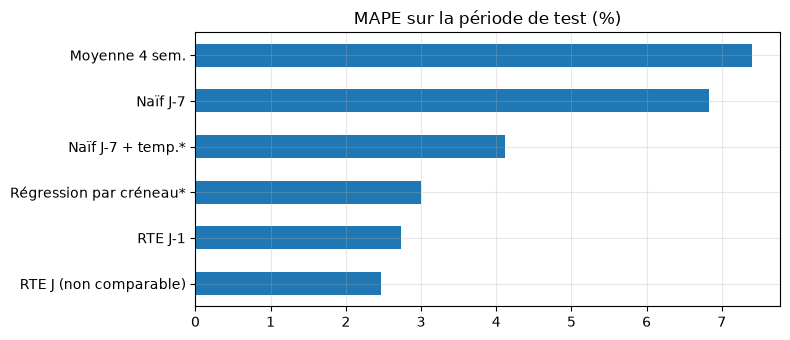

In [26]:
res = pd.DataFrame({MODELS[m]: metrics(EV["y"], EV[m], SCALE) for m in MODELS}).T
res = res.astype({"n": int})
display(res.round({"MAE": 0, "RMSE": 0, "MAPE %": 2, "biais": 0, "MASE": 3}))
print("* = utilise la météo observée (cas oracle) : borne haute des performances")

fig, ax = plt.subplots(figsize=(8, 3.5))
res["MAPE %"].sort_values().plot.barh(ax=ax, color="tab:blue")
ax.set_title("MAPE sur la période de test (%)"); ax.set_ylabel("")
plt.tight_layout(); save_fig("baselines_mape")

REPORTS.mkdir(exist_ok=True)
res.to_csv(REPORTS / "metrics_baselines_test.csv")

## 4. Où se trompent les baselines ?

MAE (MW) par type de jour :


,Naïf J-7,Naïf J-7 + temp.*,Régression par créneau*,RTE J-1,n
type_jour,,,,,
dimanche,3718.0,1636.0,1441.0,1466.0,3738
férié,5369.0,3971.0,1794.0,2129.0,816
pont,4778.0,2499.0,1415.0,1212.0,336
samedi,3859.0,1773.0,1336.0,1455.0,3696
semaine,3514.0,2149.0,1543.0,1312.0,17616


MAE (MW) par tranche de température nationale (°C) :


,Naïf J-7,Naïf J-7 + temp.*,Régression par créneau*,RTE J-1
tranche_T,,,,
<0,11008.0,4216.0,2993.0,1505.0
0-5,6669.0,2339.0,1707.0,1477.0
5-10,4612.0,1988.0,1366.0,1200.0
10-15,3477.0,1975.0,1428.0,1378.0
15-20,1994.0,1774.0,1485.0,1427.0
20-25,1954.0,1961.0,1360.0,1475.0
>25,2829.0,3044.0,1943.0,1535.0


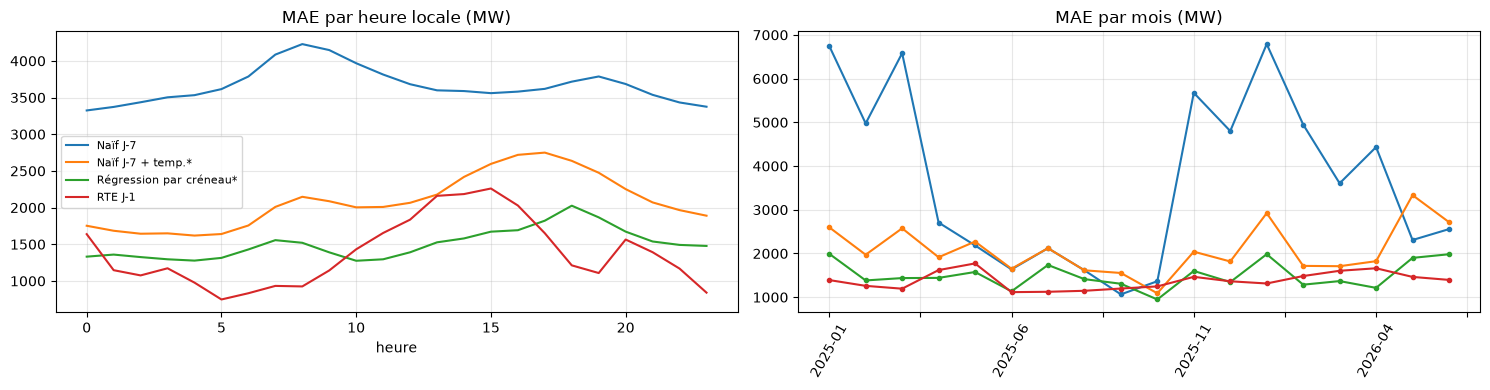

In [27]:
loc_ix = EV.index.tz_convert(TZ)
E = EV.copy()
E["heure"] = loc_ix.hour
E["mois"] = loc_ix.strftime("%Y-%m")
day_ev = loc_ix.tz_localize(None).normalize()

flags = df.loc[EV.index, ["is_holiday", "is_bridge"]]
E["type_jour"] = np.select(
    [flags["is_holiday"].to_numpy(), flags["is_bridge"].to_numpy(), loc_ix.dayofweek == 6, loc_ix.dayofweek == 5],
    ["férié", "pont", "dimanche", "samedi"], default="semaine")
E["tranche_T"] = pd.cut(df.loc[EV.index, "temp_nat"], [-np.inf, 0, 5, 10, 15, 20, 25, np.inf],
                        labels=["<0", "0-5", "5-10", "10-15", "15-20", "20-25", ">25"])

show = ["naive_7d", "naive_7d_temp", "reg_slot", "rte_j1"]
abs_err = {m: (E[m] - E["y"]).abs() for m in show}

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for m in show:
    abs_err[m].groupby(E["heure"]).mean().plot(ax=axes[0], label=MODELS[m])
    abs_err[m].groupby(E["mois"]).mean().plot(ax=axes[1], label=MODELS[m], marker="o", ms=3)
axes[0].set_title("MAE par heure locale (MW)"); axes[0].legend(fontsize=8); axes[0].set_xlabel("heure")
axes[1].set_title("MAE par mois (MW)"); axes[1].tick_params(axis="x", rotation=60); axes[1].set_xlabel("")
plt.tight_layout(); save_fig("baselines_mae_heure_mois")

tab_jour = pd.DataFrame({MODELS[m]: abs_err[m].groupby(E["type_jour"]).mean() for m in show})
tab_temp = pd.DataFrame({MODELS[m]: abs_err[m].groupby(E["tranche_T"], observed=True).mean() for m in show})
print("MAE (MW) par type de jour :"); display(tab_jour.round(0).assign(n=E["type_jour"].value_counts()))
print("MAE (MW) par tranche de température nationale (°C) :"); display(tab_temp.round(0))

In [28]:
# Pointe journalière : le maximum du jour est ce qui compte pour le réseau
peak = EV.groupby(day_ev).max()
rows = {}
for m in MODELS:
    e = peak[m] - peak["y"]
    rows[MODELS[m]] = {"MAE pointe (MW)": e.abs().mean(), "MAPE pointe %": (e.abs() / peak["y"]).mean() * 100,
                       "biais pointe (MW)": e.mean(), "jours": len(e)}
display(pd.DataFrame(rows).T.round({"MAE pointe (MW)": 0, "MAPE pointe %": 2, "biais pointe (MW)": 0}))

,MAE pointe (MW),MAPE pointe %,biais pointe (MW),jours
Naïf J-7,3725.0,6.13,147.0,546.0
Moyenne 4 sem.,3926.0,6.53,281.0,546.0
Naïf J-7 + temp.*,2054.0,3.60,-125.0,546.0
Régression par créneau*,1466.0,2.57,-401.0,546.0
RTE J-1,1418.0,2.56,-1174.0,546.0
RTE J (non comparable),1254.0,2.31,-1221.0,546.0


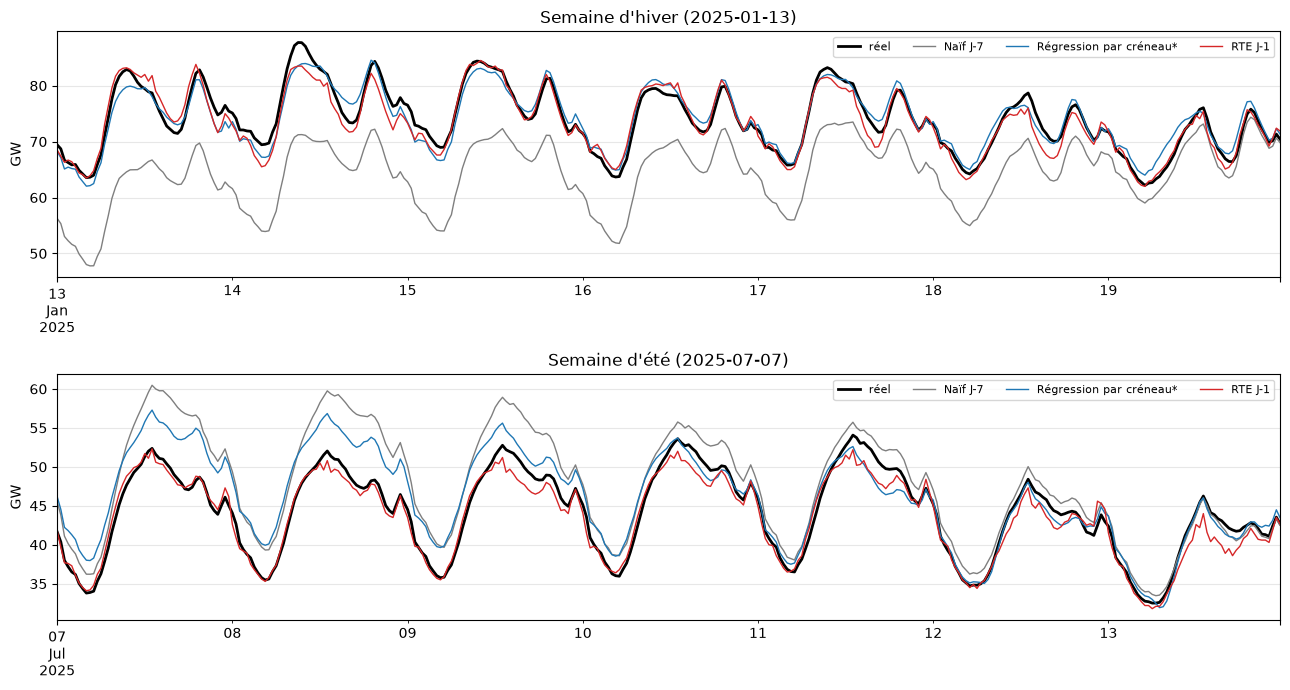

In [29]:
# Deux semaines types : hiver et été
wk = EV.copy()
wk.index = wk.index.tz_convert(TZ)
periods = [("2025-01-13", "2025-01-19", "Semaine d'hiver"), ("2025-07-07", "2025-07-13", "Semaine d'été")]
fig, axes = plt.subplots(len(periods), 1, figsize=(13, 7))
for ax, (a, b, title) in zip(axes, periods):
    w = wk.loc[a:b]
    if w.empty:
        ax.set_title(f"{title} : pas de données"); continue
    (w["y"] / 1000).plot(ax=ax, color="k", lw=2, label="réel")
    for m, c in [("naive_7d", "tab:gray"), ("reg_slot", "tab:blue"), ("rte_j1", "tab:red")]:
        (w[m] / 1000).plot(ax=ax, color=c, lw=1, label=MODELS[m])
    ax.set_title(f"{title} ({a})"); ax.set_ylabel("GW"); ax.legend(fontsize=8, ncol=4); ax.set_xlabel("")
plt.tight_layout(); save_fig("baselines_semaines_types")

## 5. Pourquoi la prévision RTE J-1 se dégrade-t-elle depuis 2023 ?

Le notebook 01 a montré une MAPE de ~1,5 % jusqu'en 2019 puis ~2,5-2,7 % depuis 2023. Trois hypothèses testables :

1. **Biais systématique** (RTE sur- ou sous-estime) : le biais signé par année le montre.
2. **Série devenue plus difficile pour tout le monde** (autoconsommation, volatilité) : le naïf J-7 se dégrade-t-il aussi ?
3. **Changement de méthode ou de définition** : rupture brutale plutôt que progressive.

On compare sur tous les points où `prevision_j1` et le naïf J-7 existent.

,MAPE RTE J-1 %,MAPE naïf J-7 %,biais RTE %,biais RTE MW
date_heure,,,,
2013,1.51,6.92,-0.84,-478.52
2014,1.42,4.90,-0.86,-455.03
2015,1.40,5.68,-0.47,-281.25
2016,1.46,5.98,-0.30,-191.11
2017,1.47,6.24,-0.20,-125.62
2018,1.55,7.04,-0.71,-398.59
2019,1.46,6.00,-0.39,-228.12
2020,1.60,6.01,-0.25,-114.90
2021,1.62,7.10,-0.46,-226.52


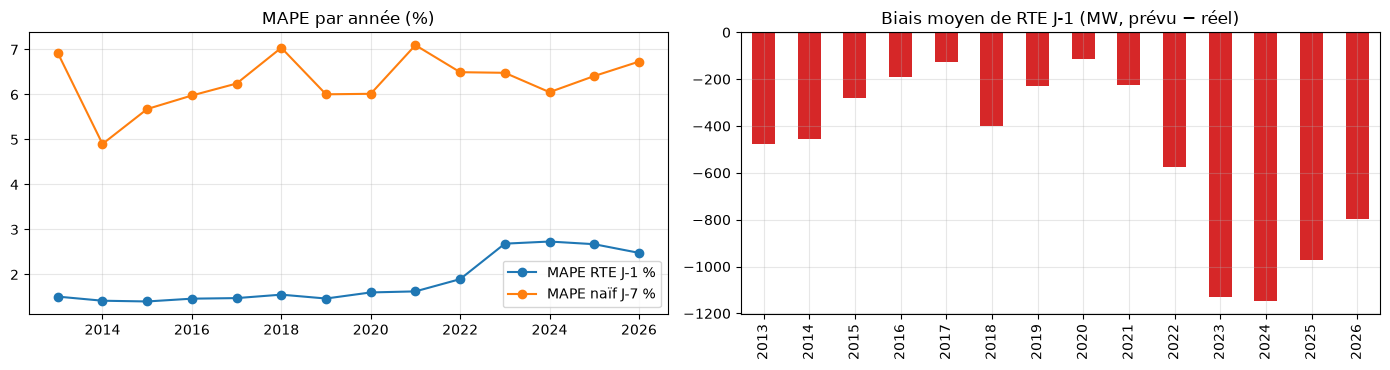

In [30]:
D = pd.DataFrame({"y": y, "rte_j1": df["prevision_j1"], "naive_7d": X["lag7"]}).dropna()
yr = D.index.tz_convert(TZ).year


def per_year(pred):
    e = D[pred] - D["y"]
    g = pd.DataFrame({"abs_pct": e.abs() / D["y"] * 100, "signed_pct": e / D["y"] * 100, "signed_mw": e})
    return g.groupby(yr).mean()


ry, ny = per_year("rte_j1"), per_year("naive_7d")
diag = pd.DataFrame({"MAPE RTE J-1 %": ry["abs_pct"], "MAPE naïf J-7 %": ny["abs_pct"],
                     "biais RTE %": ry["signed_pct"], "biais RTE MW": ry["signed_mw"]})
display(diag.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
diag[["MAPE RTE J-1 %", "MAPE naïf J-7 %"]].plot(ax=axes[0], marker="o")
axes[0].set_title("MAPE par année (%)"); axes[0].set_xlabel("")
diag["biais RTE MW"].plot.bar(ax=axes[1], color="tab:red")
axes[1].axhline(0, color="k", lw=0.8); axes[1].set_title("Biais moyen de RTE J-1 (MW, prévu − réel)"); axes[1].set_xlabel("")
plt.tight_layout(); save_fig("diagnostic_rte")

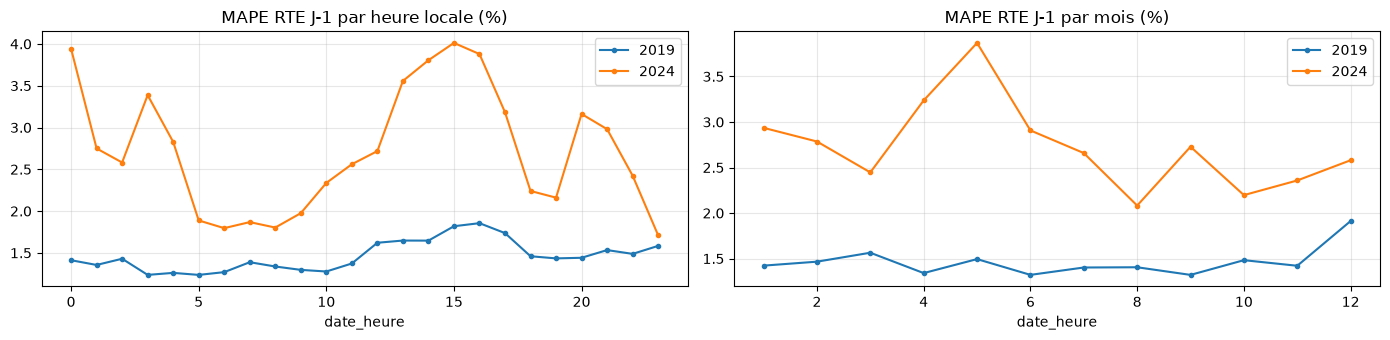

In [31]:
# Où se situe la dégradation dans la journée et dans l'année ? (2019 vs 2024)
e = (D["rte_j1"] - D["y"]).abs() / D["y"] * 100
loc_d = D.index.tz_convert(TZ)
cmp_ = pd.DataFrame({"2019": e[yr == 2019].groupby(loc_d[yr == 2019].hour).mean(),
                     "2024": e[yr == 2024].groupby(loc_d[yr == 2024].hour).mean()})
cmp_m = pd.DataFrame({"2019": e[yr == 2019].groupby(loc_d[yr == 2019].month).mean(),
                      "2024": e[yr == 2024].groupby(loc_d[yr == 2024].month).mean()})
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
cmp_.plot(ax=axes[0], marker="o", ms=3, title="MAPE RTE J-1 par heure locale (%)")
cmp_m.plot(ax=axes[1], marker="o", ms=3, title="MAPE RTE J-1 par mois (%)")
plt.tight_layout()

**Lecture (données réelles) :**
- **Ce n'est pas la série qui est devenue plus difficile.** La MAPE du naïf J-7 reste stable, entre 5 et 7 %, de 2013 à 2026. La dégradation est propre à la prévision RTE : 1,4-1,6 % jusqu'en 2021, 1,9 % en 2022, puis 2,5-2,7 % depuis 2023.
- **Le biais est systématique.** RTE J-1 sous-estime chaque année (−0,2 à −0,9 % de 2013 à 2021), puis −1,1 % en 2022, −2,3 % en 2023-2024 (≈ −1,1 GW), −2,0 % en 2025 et −1,5 % en 2026. Sur le test, `prevision_j` (mise à jour dans la journée, avec plus d'information) a **le même biais** (−1,1 GW) : cela ressemble à un décalage de définition ou de calibration entre la prévision et la série de référence, pas à un manque d'information.
- **Le profil horaire a changé.** En 2019 la MAPE est plate (~1,3-1,9 %). En 2024 elle atteint 3,9 % à 0 h, 3,4 % à 3 h, ~4 % à 15 h et ~3 % à 20-21 h, avec un maximum en avril-mai (3,9 %). Hypothèses à vérifier : solaire en autoconsommation l'après-midi et au printemps, pilotage des usages (heures creuses) la nuit et le soir.
- Question ouverte, traitée dans la cellule suivante : ce biais tient-il à la nature de la donnée de référence (consolidée ou temps réel) ?

In [ ]:
# Le biais de RTE J-1 vient-il de la série de référence ? (consolidée vs temps réel)
ref_col = "nature" if "nature" in df.columns else "source"
Dn = pd.DataFrame({"y": y, "rte_j1": df["prevision_j1"], "rte_j": df["prevision_j"], "ref": df[ref_col]}).dropna(subset=["y", "rte_j1"])
Dn["annee"] = Dn.index.tz_convert(TZ).year
Dn["biais J-1 %"] = (Dn["rte_j1"] - Dn["y"]) / Dn["y"] * 100
Dn["biais J %"] = (Dn["rte_j"] - Dn["y"]) / Dn["y"] * 100
print("Biais moyen de RTE (prévu - réel, en % du réel) selon la nature de la donnée de référence :")
display(Dn[Dn["annee"] >= 2023].groupby(["annee", "ref"])[["biais J-1 %", "biais J %"]].agg(["mean", "size"]).round(2))

# RTE J-1 « débiaisé » : on retranche le biais moyen des 28 derniers jours connus (causal : jusqu'à T-2)
day_F = F.index.tz_convert(TZ).tz_localize(None).normalize()
err_day = (F["rte_j1"] - F["y"]).groupby(day_F).mean().asfreq("D")
bias_est = err_day.shift(2).rolling(28, min_periods=14).mean()
F["rte_j1_debiaise"] = F["rte_j1"] - pd.Series(bias_est.reindex(day_F).to_numpy(), index=F.index)

cols = ["y", "reg_slot", "rte_j1", "rte_j1_debiaise"]
EV2 = F.loc[test_mask, cols].dropna()
names = {"reg_slot": "Régression par créneau*", "rte_j1": "RTE J-1", "rte_j1_debiaise": "RTE J-1 débiaisé (28 j)"}
cmp2 = pd.DataFrame({v: metrics(EV2["y"], EV2[k], SCALE) for k, v in names.items()}).T.astype({"n": int})
display(cmp2.round({"MAE": 0, "RMSE": 0, "MAPE %": 2, "biais": 0, "MASE": 3}))
print("* = météo observée (oracle). Le RTE J-1 débiaisé donne la dispersion « pure » de RTE : c'est le vrai niveau à atteindre.")

In [32]:
out = F.loc[test_mask].copy()
out.to_parquet(PROC / "baselines_test_predictions.parquet")
print(f"{PROC / 'baselines_test_predictions.parquet'} ({len(out):,} lignes)")
print(f"{REPORTS / 'metrics_baselines_test.csv'}")
print(f"\nConfiguration retenue : début {TRAIN_START_FINAL} | exclusion du confinement : {EXCLUDE_COVID_FINAL} | beta = {BETA:,.0f}")

c:\Users\baptm\Downloads\conso-rte\data\processed\baselines_test_predictions.parquet (26,206 lignes)
c:\Users\baptm\Downloads\conso-rte\reports\metrics_baselines_test.csv

Configuration retenue : début 2020-07-01 | exclusion du confinement : False | beta = 1,719


## 6. Bilan

### Score à battre (test : janvier 2025 → juin 2026, 26 202 points communs)

| Modèle | MAE (MW) | MAPE | Biais (MW) | MASE |
|---|---|---|---|---|
| Naïf J-7 | 3 666 | 6,83 % | +154 | 1,03 |
| Moyenne 4 semaines | 3 921 | 7,40 % | +482 | 1,10 |
| Naïf J-7 + température* | 2 084 | 4,11 % | −119 | 0,58 |
| Régression par créneau* | 1 505 | 3,00 % | −8 | 0,42 |
| **RTE J-1** | **1 379** | **2,74 %** | −1 055 | 0,39 |
| RTE J (non comparable) | 1 239 | 2,46 % | −1 097 | 0,35 |

\* météo observée (cas oracle) : borne haute des performances.

### Ce qu'on en retient

- **La météo est le premier levier.** Corriger le naïf J-7 de la température fait passer la MAE de 3 666 à 2 084 MW (−43 %). Le calendrier, le niveau récent et la forme de la courbe ajoutent encore −28 % (1 505 MW).
- **On n'a pas encore battu RTE J-1**, même avec une météo parfaite : 1 505 contre 1 379 MW de MAE (+9 %). La comparaison brute flatte pourtant notre modèle : RTE porte un biais de −1 GW. Sans ce biais, son erreur quadratique serait d'environ 1 360 MW contre 1 950 MW pour nous, soit ~30 % de dispersion en plus de notre côté. La cellule de diagnostic ci-dessus quantifie ce niveau « débiaisé ».
- **Sur la pointe journalière, on est au niveau de RTE** : MAE de 1 466 MW contre 1 418 MW, MAPE de 2,57 % contre 2,56 %.
- **Fenêtre d'entraînement :** l'ablation ne tranche pas (écarts ≤ 3 %). Choix : novembre 2017 (a priori), sans exclusion du confinement. À refaire avec LightGBM.

### Où se situe l'erreur

- **Froid :** à moins de 0 °C la MAE est de 2 993 MW contre 1 505 MW pour RTE, et de 1 707 contre 1 477 MW entre 0 et 5 °C. Explications probables : peu d'exemples de froid intense dans un entraînement démarrant en 2020, et une relation non linéaire mal captée par notre forme quadratique.
- **Type de jour :** on fait mieux que RTE le week-end (1 336-1 441 MW contre 1 455-1 466 MW) et les jours fériés (1 794 contre 2 129 MW), moins bien en semaine (1 543 contre 1 312 MW) et les jours de pont (1 415 contre 1 212 MW). La semaine pèse les deux tiers des points.
- **Heure :** notre erreur est assez plate. RTE est meilleur de 1 h à 9 h (≈ 750-1 200 MW contre 1 300-1 550 MW) et de 18 h à 19 h (≈ 1 100-1 200 MW contre 1 900-2 000 MW), mais moins bon de 12 h à 16 h (≈ 1 800-2 300 MW contre 1 300-1 700 MW).
- **Été :** en semaine chaude (7-13 juillet 2025), on surestime le milieu de journée. Le solaire en autoconsommation n'est pas capté : `rad_nat` et `cloud_nat` ne sont pas encore utilisés.